### 1. Import the libraries

#### 1.1. Import the needed libraries

In [1]:
from utils.data_loader import DatasetLoader
from utils.data_visualization import DataVisualization
from utils.preprocessing import Preprocessor
from utils.feature_selection import MutualInformation
from utils.models import ensemble_models
from utils.model_evaluator import ModelEvaluator
from utils.tree_shap import SHAPTreeExplainer


import warnings
warnings.filterwarnings('ignore')


#### 1.2. Define the global variables 

In [2]:
binary_target = 'Type' 
multiclass_target = 'Type of attack' 
all_target_columns = [binary_target, multiclass_target]
columns_to_drop = ["No.", "Source", "Destination", "Info"]
categorical_missing_token = None
numeric_imputation_strategy = 'median'
categorical_imputation_strategy = 'most_frequent'
shuffle=True
random_state=80


### 2. Load the dataset

In [3]:
ECU_IoHT_loader = DatasetLoader(dataset_name="ECU_IoHT")

df = ECU_IoHT_loader.load()
df = ECU_IoHT_loader.remove_duplicate(df)
df


Duplicated rows: 0
Dataframe shape: (111207, 9)


,No.,Time,Source,Destination,Protocol,Length,Info,Type,Type of attack
0,1,0.000000,Alfa_97:cf:63,Broadcast,ARP,42,Who has 192.168.43.1? Tell 192.168.43.186,Attack,ARP Spoofing
1,2,0.002956,6e:c7:ec:3c:f2:ba,Alfa_97:cf:63,ARP,42,192.168.43.1 is at 6e:c7:ec:3c:f2:ba,Attack,ARP Spoofing
2,3,0.200725,Alfa_97:cf:63,Broadcast,ARP,42,Who has 192.168.43.1? Tell 192.168.43.186,Attack,ARP Spoofing
3,4,0.202713,192.168.43.186,192.168.43.1,DNS,85,Standard query 0x0c44 PTR 1.43.168.192.in-addr...,Normal,No Attack
4,5,0.411565,6e:c7:ec:3c:f2:ba,Alfa_97:cf:63,ARP,42,192.168.43.1 is at 6e:c7:ec:3c:f2:ba,Attack,ARP Spoofing
...,...,...,...,...,...,...,...,...,...
111202,111203,10103.029320,Alfa_97:cf:63,6e:c7:ec:3c:f2:ba,ARP,42,Who has 192.168.43.1? Tell 192.168.43.186,Attack,ARP Spoofing
111203,111204,10103.140580,6e:c7:ec:3c:f2:ba,Alfa_97:cf:63,ARP,42,192.168.43.1 is at 6e:c7:ec:3c:f2:ba,Attack,ARP Spoofing
111204,111205,10103.383780,Alfa_97:cf:63,Broadcast,ARP,42,192.168.43.1 is at 00:c0:ca:97:cf:63 (duplicat...,Attack,ARP Spoofing
111205,111206,10106.386960,Alfa_97:cf:63,Broadcast,ARP,42,192.168.43.1 is at 00:c0:ca:97:cf:63 (duplicat...,Attack,ARP Spoofing


### 3. Data Exploration

#### 3.1. Basic Data Analysis

In [4]:
ECU_IoHT_loader.info()

,Datatype,Not nulls,Nulls,% Nulls,Unique cnt,Mean,StDev,Min,Q25,Q50,Q75,Max
No.,int64,111207,0,0.0,111207,55604.000000,32102.840030,1.0,27802.500000,55604.000000,83405.500000,111207.00000
Time,float64,111207,0,0.0,111205,6117.077210,2337.342593,0.0,6178.693881,6745.549357,7311.923211,10109.39032
Source,object,111207,0,0.0,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination,object,111207,0,0.0,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol,object,111207,0,0.0,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,int64,111207,0,0.0,794,112.661091,287.895879,42.0,42.000000,42.000000,54.000000,1474.00000
Info,object,111207,0,0.0,24010,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,object,111207,0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type of attack,object,111207,0,0.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 3.2. Target Features

In [5]:
viz = DataVisualization(
    df,
    label_columns=all_target_columns
)


##### 3.2.1. Binary class

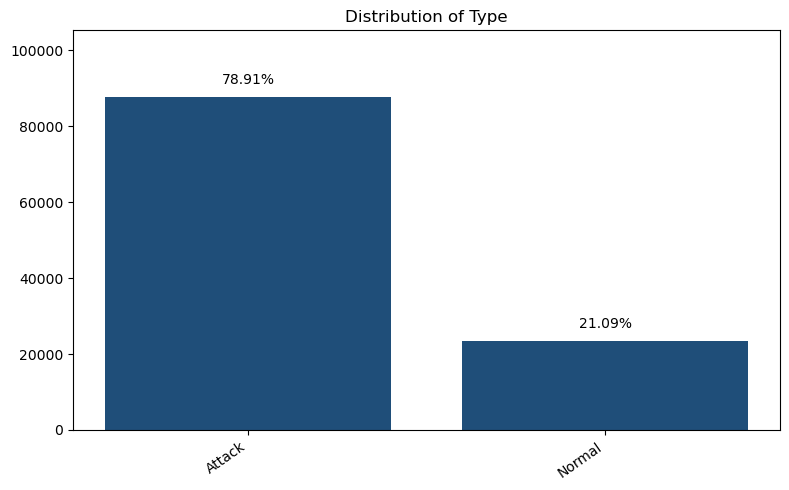

In [6]:
viz.target_distribution(
    label_column=binary_target
)


##### 3.2.2. Multiclass

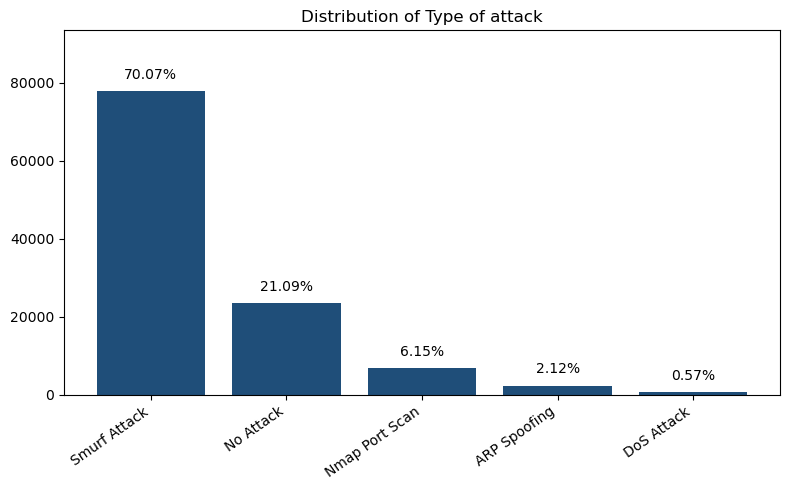

In [7]:
viz.target_distribution(label_column=multiclass_target)


#### 3.3. Numerical Data

Histogram

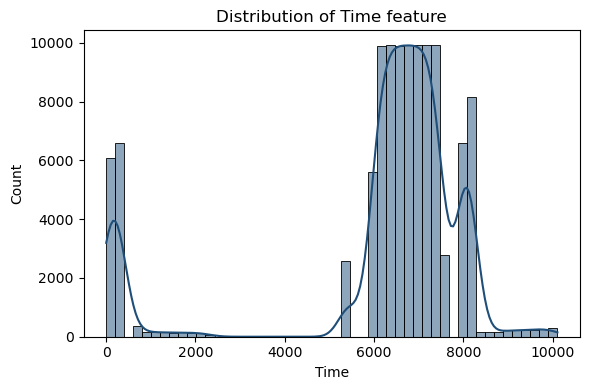

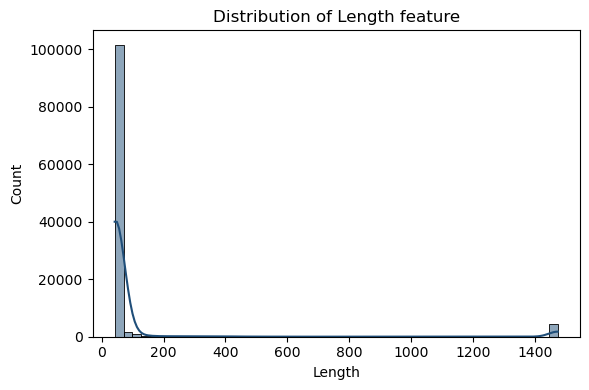

In [10]:
viz.numeric_distribution()


Boxplot

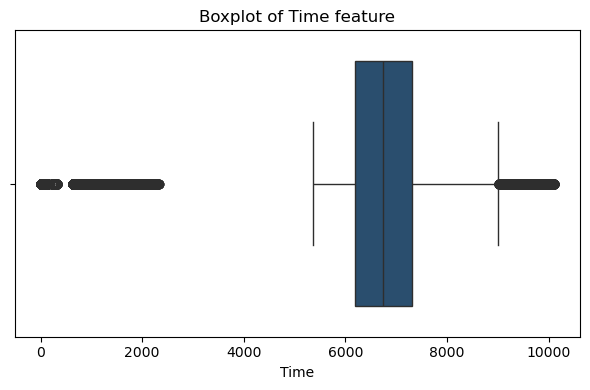

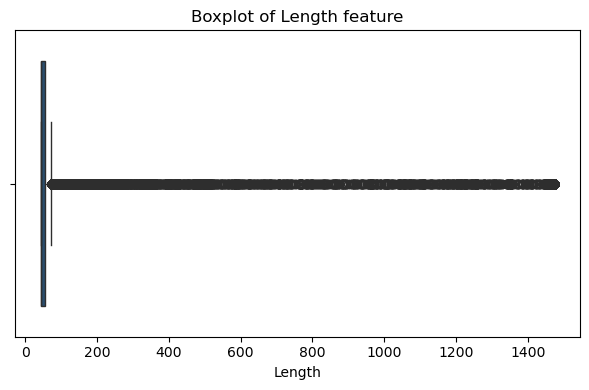

In [11]:
viz.boxplot()

#### 3.4. Categorical Data

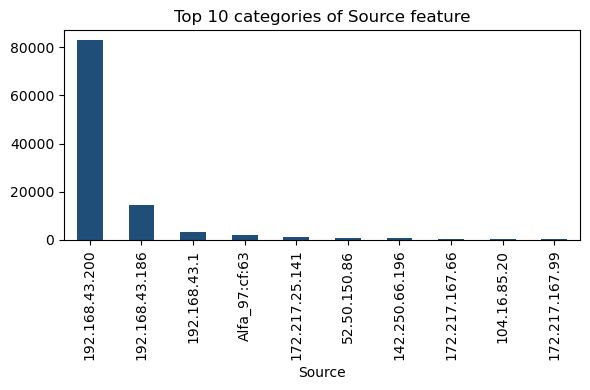

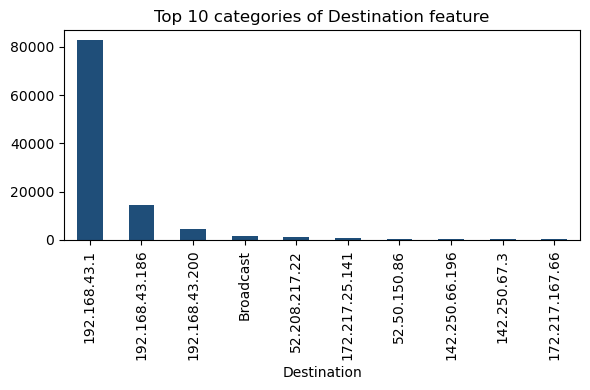

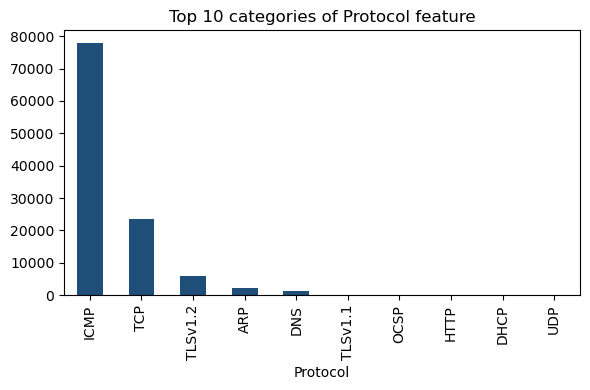

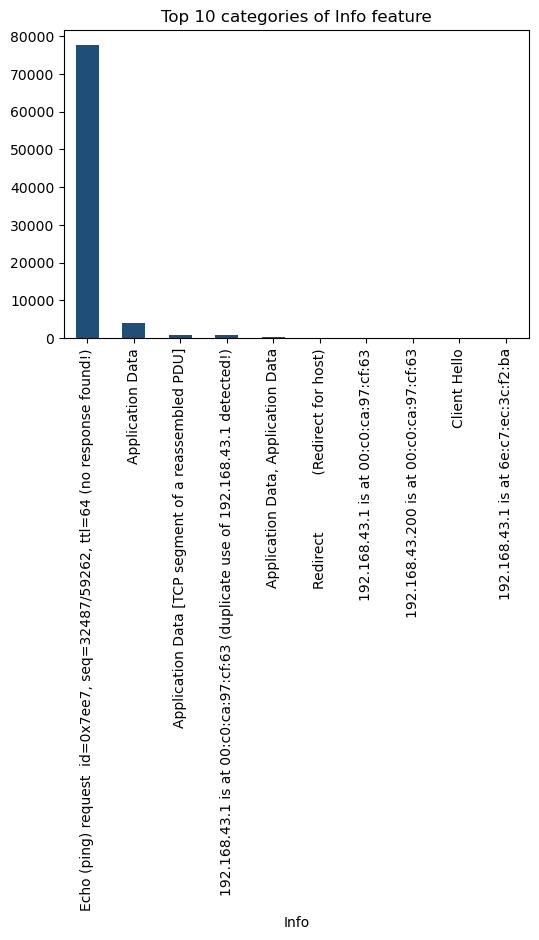

In [13]:
viz.categorical_distribution()

### 4. Preprocessing

#### 4.1. Binary class

In [5]:
preprocessor_BC = Preprocessor(
    target_column=binary_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_BC = preprocessor_BC.prepare_features(df)

X_BC = df_BC.drop(columns=[binary_target]).reset_index(drop=True)
y_BC = df_BC[binary_target].reset_index(drop=True)


['Type of attack'] target column eliminated
['No.', 'Source', 'Destination', 'Info'] columns eliminated


#### 4.2. Multiclass

In [6]:
preprocessor_MC = Preprocessor(
    target_column=multiclass_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_MC = preprocessor_MC.prepare_features(df)

X_MC = df_MC.drop(columns=[multiclass_target]).reset_index(drop=True)
y_MC = df_MC[multiclass_target].reset_index(drop=True)


['Type'] target column eliminated
['No.', 'Source', 'Destination', 'Info'] columns eliminated


### 5. Feature Selection

#### 5.1. Binary class

In [7]:
mi_BC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


#### 5.2. Multiclass

In [8]:
mi_MC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


### 6. Train the models

#### 6.1. Binary class

In [9]:
# Models with default parameters
models_BC = ensemble_models(task_type="binary", random_state=random_state)
models_BC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...)}

{'Attack': 0, 'Normal': 1}
X_train shape: (88965, 3)
y_train shape: (88965,)
X_test shape: (22242, 3)
y_test shape: (22242,)
2 numeric features: ['Time', 'Length']
1 categorical features: ['Protocol']
Total features after preprocessing: 12
Mutual Information selected 5 features: ['Length', 'Time', 'Protocol_ICMP', 'Protocol_TCP', 'Protocol_TLSv1_2']

Running model: RandomForest


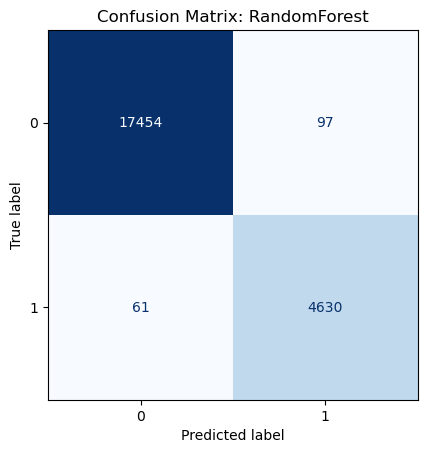


Running model: ExtraTrees


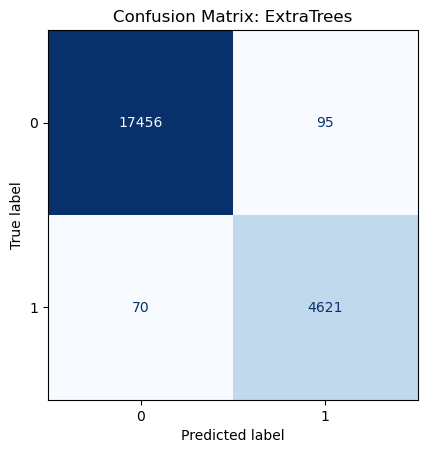


Running model: LightGBM


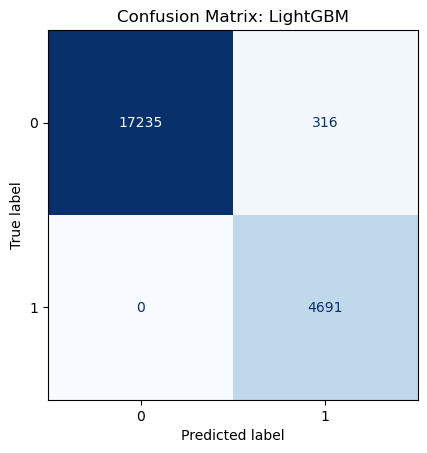


Running model: XGBoost


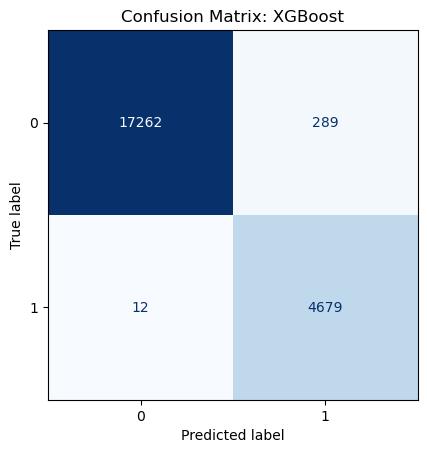

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,time
0,RandomForest,0.996916,0.992896,0.995568,0.979480,0.998276,0.986996,0.996920,0.983224,6.419203
1,ExtraTrees,0.996916,0.992582,0.996259,0.979856,0.997578,0.985078,0.996918,0.982460,2.824212
2,LightGBM,0.989943,0.985793,0.980310,0.936888,0.999972,1.000000,0.990043,0.967416,2.349935
3,XGBoost,0.989459,0.986467,0.981530,0.941828,0.997692,0.997442,0.989545,0.968837,0.388498


In [10]:
runner_BC = ModelEvaluator(
    test_size=0.2,
    random_state=random_state,
    task_type="binary"
)

results_BC = runner_BC.run(
    models=models_BC,
    preprocessor=preprocessor_BC,
    X=X_BC,
    y=y_BC,
    feature_selector=mi_BC
)

results_BC


#### 6.2. Multiclass

In [11]:
models_MC = ensemble_models(task_type="multiclass", random_state=random_state)
models_MC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...)}

{'ARP Spoofing': 0, 'DoS Attack': 1, 'Nmap Port Scan': 2, 'No Attack': 3, 'Smurf Attack': 4}
X_train shape: (88965, 3)
y_train shape: (88965,)
X_test shape: (22242, 3)
y_test shape: (22242,)
2 numeric features: ['Time', 'Length']
1 categorical features: ['Protocol']
Total features after preprocessing: 13
Mutual Information selected 6 features: ['Time', 'Length', 'Protocol_ICMP', 'Protocol_TCP', 'Protocol_ARP', 'Protocol_TLSv1_2']

Running model: RandomForest


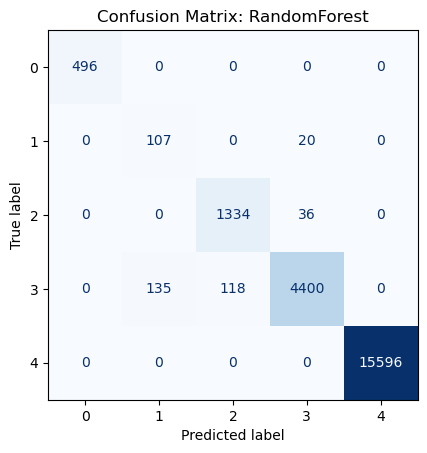


Running model: ExtraTrees


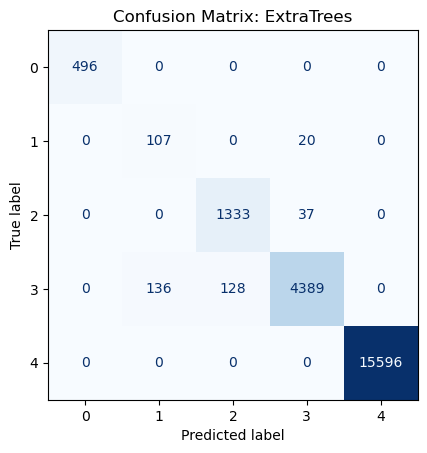


Running model: LightGBM


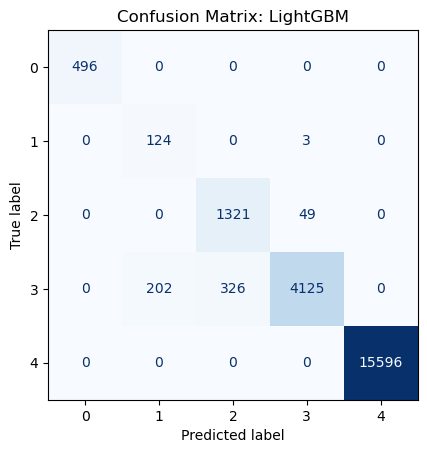


Running model: XGBoost


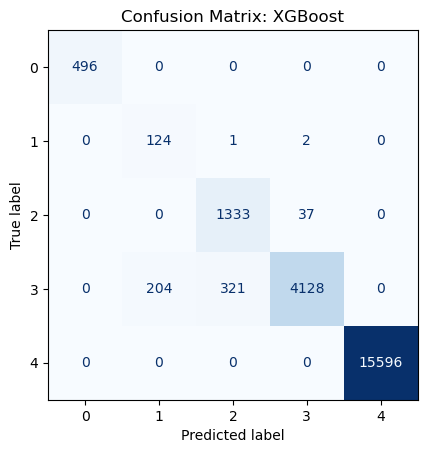

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,time
0,RandomForest,0.993174,0.986107,0.993237,0.989180,0.993174,0.986107,0.993162,0.987144,16.414369
1,ExtraTrees,0.993181,0.985568,0.993255,0.988726,0.993181,0.985568,0.993165,0.986622,7.397476
2,LightGBM,0.972900,0.973923,0.973197,0.981666,0.972900,0.973923,0.972609,0.976019,2.414487
3,XGBoost,0.974360,0.974598,0.974868,0.982507,0.974360,0.974598,0.974069,0.976715,2.238703


In [12]:
runner_MC = ModelEvaluator(
    test_size=0.2,
    random_state=random_state,
    task_type="multiclass"
)

results_MC = runner_MC.run(
    models=models_MC,
    preprocessor=preprocessor_MC,
    X=X_MC,
    y=y_MC,
    feature_selector=mi_MC
)

results_MC

# 1m 33s

### 7. TreeSHAP

#### 7.1. Multiclass

In [13]:
explainer_MC = SHAPTreeExplainer(task_type="multiclass", n_samples=5000, random_state=random_state) 

RandomForest

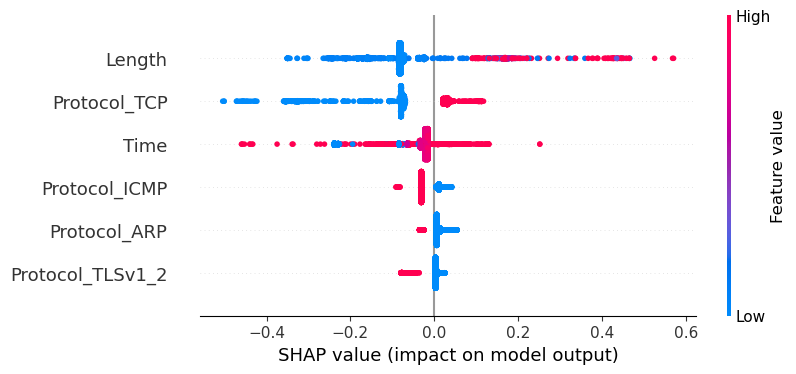

In [14]:
model_MC_rf, X_train_MC_rf, y_train_MC_rf, X_test_MC_rf, y_test_MC_rf = (
    runner_MC.get_model_data("RandomForest")
)

explainer_MC.plot_beeswarm(model_MC_rf, X_test_MC_rf, class_index=1)

ExtraTrees

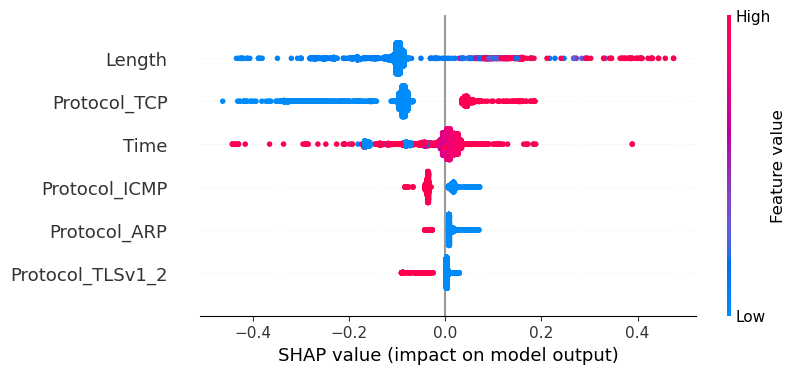

In [15]:
model_MC_et, X_train_MC_et, y_train_MC_et, X_test_MC_et, y_test_MC_et = (
    runner_MC.get_model_data("ExtraTrees")
)

explainer_MC.plot_beeswarm(model_MC_et, X_test_MC_et, class_index=1)

XGBoost

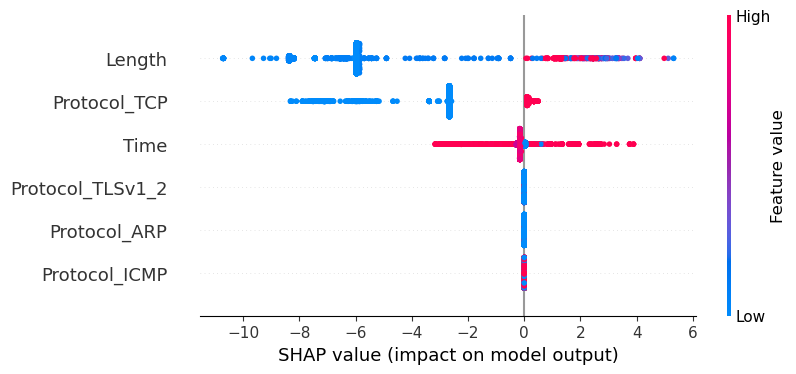

In [16]:
model_MC_xg, X_train_MC_xg, y_train_MC_xg, X_test_MC_xg, y_test_MC_xg = (
    runner_MC.get_model_data("XGBoost")
)

explainer_MC.plot_beeswarm(model_MC_xg, X_test_MC_xg, class_index=1)

LightGBM

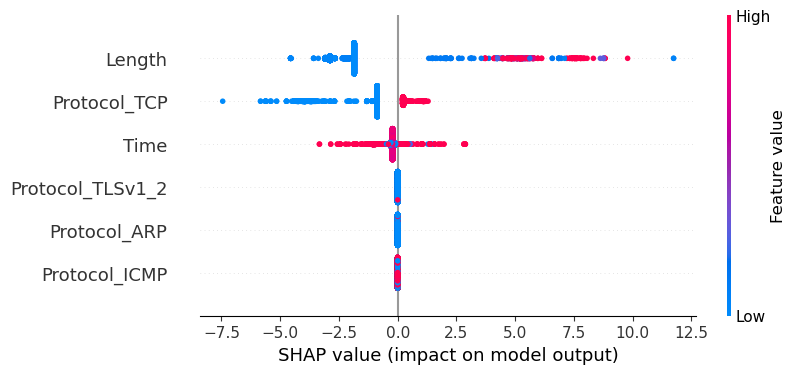

In [17]:
model_MC_lb, X_train_MC_lb, y_train_MC_lb, X_test_MC_lb, y_test_MC_lb = (
    runner_MC.get_model_data("LightGBM")
)

explainer_MC.plot_beeswarm(model_MC_lb, X_test_MC_lb, class_index=1)